## Load dataset

In [2]:
import pandas as pd

df = pd.read_excel("MASD2024_data.xlsx")

In [11]:
print("Shape:", df.shape)

display(df.head())

#df.info()



Shape: (34, 6)


,Have you ever taken a mathematics and/or statistics course before?,How much do you expect to like this course?,What grade do you expect to get in the course?,Please rate your level of experience with programming,The thought of being enrolled in a mathematics/statistics course makes me nervous.,What type of high-school did you attend?
0,Yes,4,4,6,5.0,HTX
1,Yes,5,10,7,1.0,HTX
2,No,3,4,3,4.0,STX
3,No,2,4,5,6.0,STX
4,Yes,3,4,4,6.0,HTX


## Probability mass function of expected grades

In [16]:
pmf = df["What grade do you expect to get in the course?"].value_counts(normalize=True).sort_index()

pmf

What grade do you expect to get in the course?
0     0.029412
2     0.058824
4     0.382353
7     0.264706
10    0.235294
12    0.029412
Name: proportion, dtype: float64

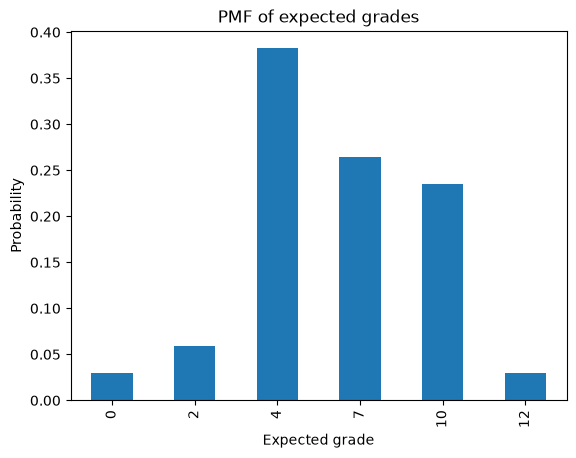

In [13]:
import matplotlib.pyplot as plt

pmf.plot(kind="bar")

plt.xlabel("Expected grade")
plt.ylabel("Probability")
plt.title("PMF of expected grades")

plt.show()

In [ ]:
import numpy as np


# Calculate the expected value of the PMF, by multiplying each grade by its probability and summing the results
expected_value = np.sum(pmf.index * pmf)

print(expected_value)

6.205882352941177


In [ ]:
ex2 = np.sum((pmf.index**2) * pmf.values)

# Calculate the variance of the PMF, by subtracting the square of the expected value from the expected value of the squared grades
variance = ex2 - expected_value**2

print(variance)


8.575259515570927


## Predicting nervousness based on high school type

In [ ]:
# Prior probability of a high nervous level (\geq 5)
# Calculate the proportion of students who reported a nervous level of 5 or higher
p_high = np.mean(df["The thought of being enrolled in a mathematics/statistics course makes me nervous."] >= 5)

print(p_high)


0.5294117647058824


In [28]:
# Calculate the conditional probability of a low nervous level (< 5) given that the student is in HTX
p_low_given_htx = np.mean(
    df[df["What type of high-school did you attend?"] == "HTX"]["The thought of being enrolled in a mathematics/statistics course makes me nervous."] < 5
)

print(p_low_given_htx)

0.5


In [ ]:
# Calculate the conditional probability of a low nervous level (< 5) given that the student is in STX
p_low_given_stx = np.mean(
    df[df["What type of high-school did you attend?"] == "STX"]["The thought of being enrolled in a mathematics/statistics course makes me nervous."] < 5
)

print(p_low_given_stx)

0.34782608695652173


In [ ]:
# Using Bayes' theorem to calculate the conditional probability of a student being in HTX given that they have a low nervous level (< 5)
p_htx = np.mean(df["What type of high-school did you attend?"] == "HTX")
p_low = np.mean(df["The thought of being enrolled in a mathematics/statistics course makes me nervous."] < 5)
p_htx_given_low = (
    p_low_given_htx * p_htx
) / p_low

print(p_htx_given_low)

0.38461538461538464


In [ ]:
# Using Bayes' theorem to calculate the conditional probability of a student being in STX given that they have a low nervous level (< 5)
p_stx = np.mean(df["What type of high-school did you attend?"] == "STX")
p_stx_given_low = (
    p_low_given_stx * p_stx
) / p_low

print(p_stx_given_low)

0.6153846153846154


## Modelling expected grades with a cumulative distribution function

## Normal distribution